# Relational schema graphs

Builds the explicit schema graph (tables, columns, primary / foreign keys) and the relation matrix fed to the relation-aware encoder, for a synthetic example and a Spider dev example.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
pd.set_option("display.max_colwidth", 200)

In [2]:
from ratsql.schema.schema import load_schemas
from ratsql.schema.graph import SchemaGraph
from ratsql.schema.relations import RelationMatrixBuilder
from ratsql.schema.linking import SchemaLinks, describe_links
from ratsql.schema.visualize import plot_schema_graph, plot_relation_matrix, element_labels
from ratsql.utils.io import read_jsonl

## Synthetic running example: *Which employees work in Hyderabad?*

Database: company
  department(dept_id:number[PK], name:text, city:text, budget:number)
  employee(emp_id:number[PK], name:text, age:number, city:text, salary:number, dept_id:number[FK->department.dept_id])
  project(proj_id:number[PK], title:text, budget:number, dept_id:number[FK->department.dept_id])
'employees' -> TABLE employee [EM]
'employees' -> COLUMN employee.emp_id [PM]
'Hyderabad' -> COLUMN employee.city [VEM]
'Hyderabad' -> VALUE 'Hyderabad' in employee.city [VEM]
{'cc_fk_backward': 2, 'cc_fk_forward': 2, 'cc_same_table': 54, 'cq_pm': 1, 'cq_vem': 1, 'ct_any_table': 3, 'ct_belongs_to': 11, 'ct_foreign_key': 2, 'ct_primary_key': 3, 'qc_pm': 1, 'qc_vem': 1, 'qt_em': 1, 'tc_any_table': 3, 'tc_belongs_to': 11, 'tc_foreign_key': 2, 'tc_primary_key': 3, 'tq_em': 1, 'tt_fk_backward': 2, 'tt_fk_forward': 2}


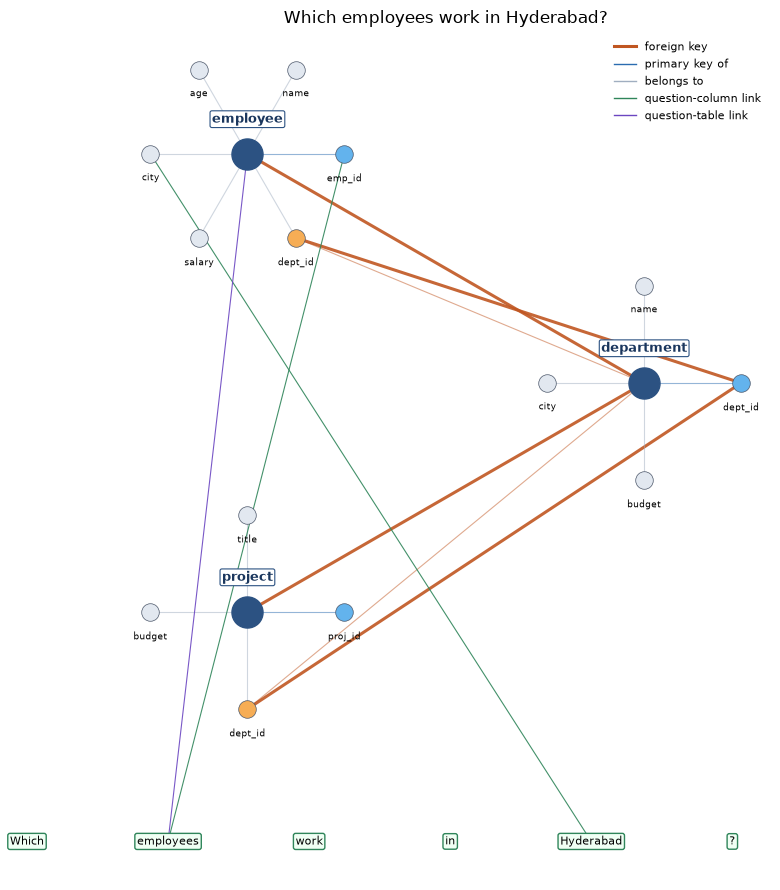

In [3]:
schemas = load_schemas(ROOT / "data/samples/synthetic/tables.json")
recs = read_jsonl(ROOT / "data/processed/synthetic/train.jsonl")
ex = next(r for r in recs if r["question"] == "Which employees work in Hyderabad?")
schema = schemas[ex["db_id"]]
print(schema.summary())
links = SchemaLinks.from_json(ex["links"])
print("\n".join(describe_links(ex["question_tokens"], schema, links)))
g = SchemaGraph.from_schema(schema).add_question(ex["question_tokens"], links)
print(g.edge_counts())
plot_schema_graph(g, title=ex["question"]);

matrix (24, 24) relation types used: 34


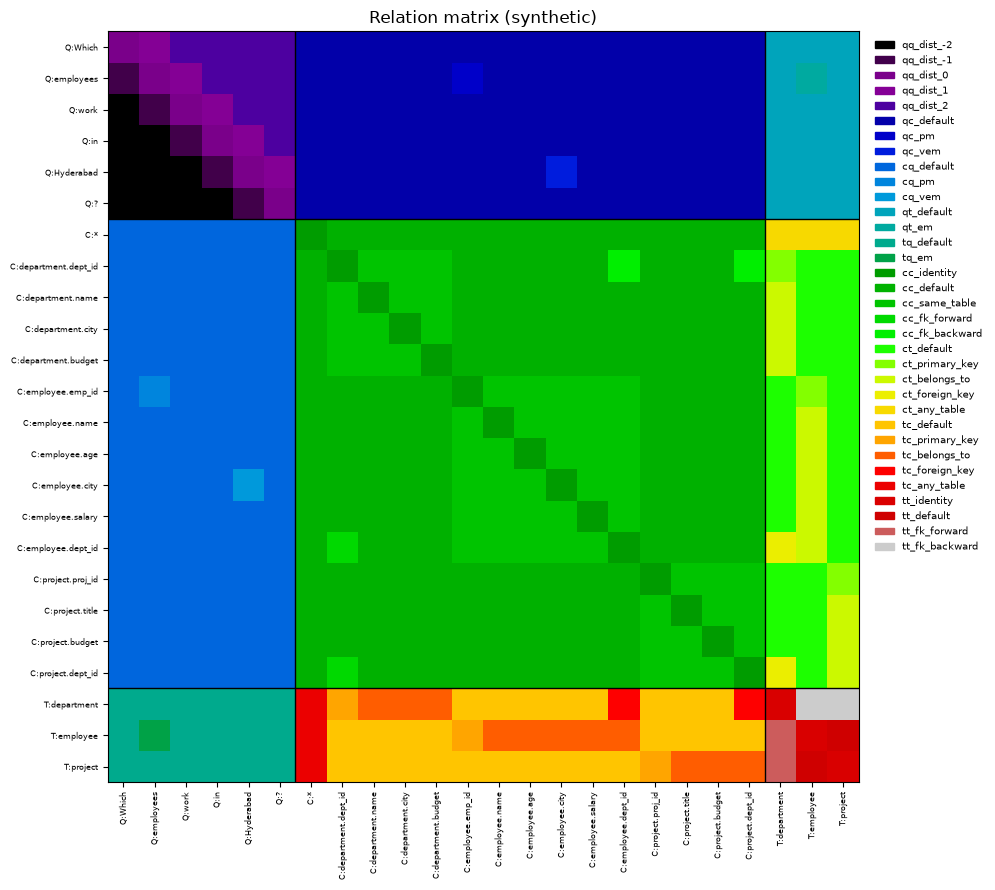

In [4]:
rb = RelationMatrixBuilder({})
m = rb.build(schema, len(ex["question_tokens"]), links)
print("matrix", m.ids.shape, "relation types used:", len(m.counts()))
plot_relation_matrix(m, element_labels(schema, ex["question_tokens"]), title="Relation matrix (synthetic)");

## Spider dev example

Show the stadium name and the number of concerts in each stadium. 
 SELECT T2.name ,  count(*) FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id  =  T2.stadium_id GROUP BY T1.stadium_id
'stadium' -> TABLE stadium [EM]
'concerts' -> TABLE concert [EM]
'concerts' -> TABLE singer_in_concert [PM]
'stadium' -> TABLE stadium [EM]
'stadium' -> COLUMN stadium.Stadium_ID [PM]
'stadium' -> COLUMN stadium.Name [VPM]
'stadium' -> COLUMN concert.Stadium_ID [PM]
'name' -> COLUMN stadium.Name [EM]
'name' -> COLUMN singer.Name [EM]
'name' -> COLUMN singer.Song_Name [PM]
'name' -> COLUMN concert.concert_Name [PM]
'concerts' -> COLUMN concert.concert_ID [PM]
'concerts' -> COLUMN concert.concert_Name [PM]
'concerts' -> COLUMN singer_in_concert.concert_ID [PM]
'stadium' -> COLUMN stadium.Stadium_ID [PM]
'stadium' -> COLUMN stadium.Name [VPM]
'stadium' -> COLUMN concert.Stadium_ID [PM]
'stadium' -> VALUE 'Bayview Stadium' in stadium.Name [VPM]
'stadium' -> VALUE 'Forthbank Stadium' in stadium.Name [VP

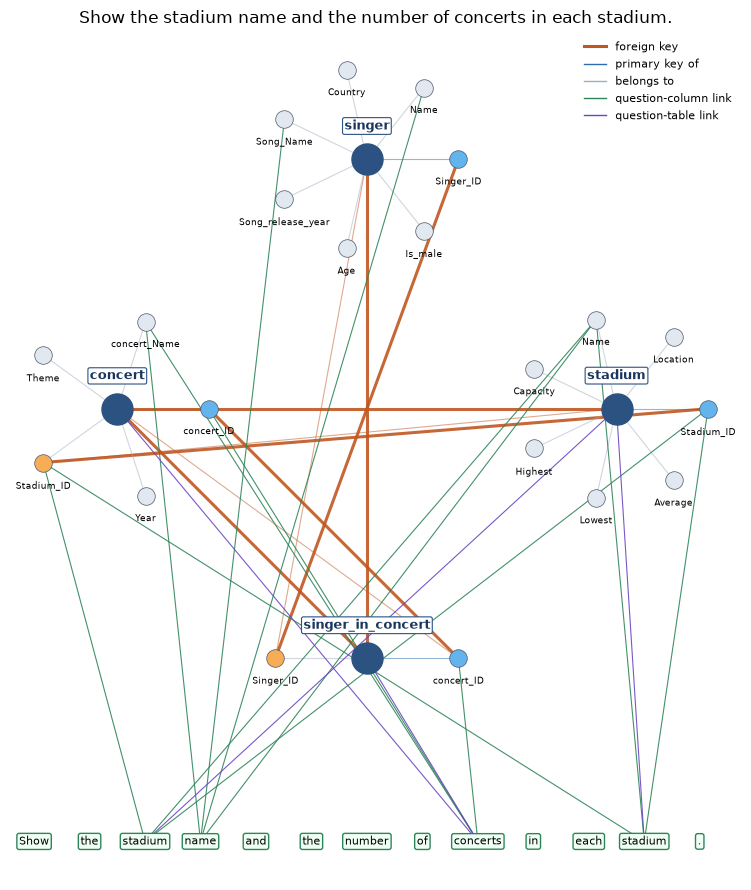

In [5]:
spider_schemas = load_schemas(next((ROOT / "data/raw").rglob("tables.json")))
dev = read_jsonl(ROOT / "data/processed/spider/dev.jsonl")
ex = next(r for r in dev if r["db_id"] == "concert_singer" and "stadium" in r["question"].lower() and "JOIN" in r["query"])
schema = spider_schemas[ex["db_id"]]
print(ex["question"], "\n", ex["query"])
links = SchemaLinks.from_json(ex["links"])
print("\n".join(describe_links(ex["question_tokens"], schema, links)))
g = SchemaGraph.from_schema(schema).add_question(ex["question_tokens"], links)
plot_schema_graph(g, title=ex["question"]);

cc_default        350
qc_default        273
cq_default        273
cc_same_table     106
qq_dist_2          66
qq_dist_-2         66
tc_default         60
ct_default         60
tq_default         48
qt_default         48
cc_identity        22
tc_belongs_to      17
ct_belongs_to      17
qq_dist_0          13
qq_dist_1          12
qq_dist_-1         12
cq_pm               9
qc_pm               9
tt_default          6
ct_primary_key      4
dtype: int64

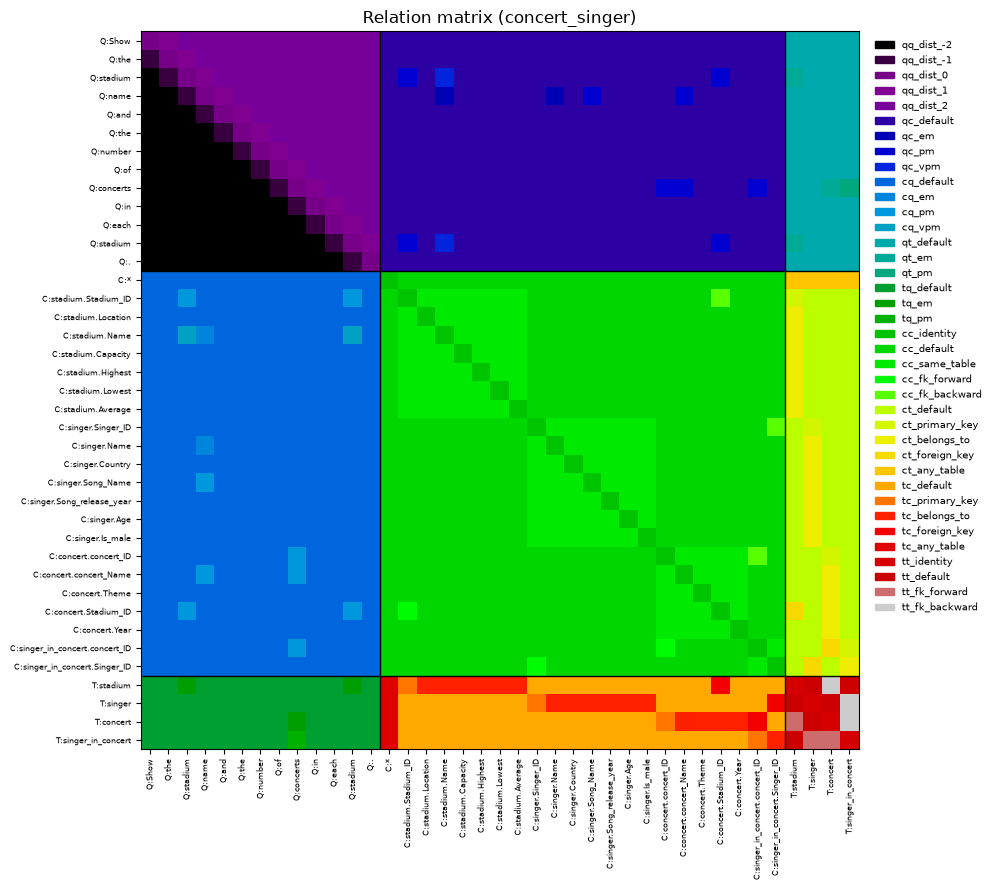

In [6]:
m = rb.build(schema, len(ex["question_tokens"]), links)
plot_relation_matrix(m, element_labels(schema, ex["question_tokens"]), title="Relation matrix (concert_singer)");
pd.Series(m.counts()).sort_values(ascending=False).head(20)

## Schema-graph statistics over all Spider databases

In [7]:
stats = ROOT / "results/tables/schema_graph_stats.csv"
df = pd.read_csv(stats) if stats.exists() else None
df[["tables", "columns", "primary_keys", "foreign_keys", "schema_edges"]].describe().round(1) if df is not None else "run scripts/build_schema_graphs.py first"

,tables,columns,primary_keys,foreign_keys,schema_edges
count,166.0,166.0,166.0,166.0,166.0
mean,5.3,27.1,4.7,4.8,283.7
std,3.9,30.8,3.4,4.8,670.3
min,2.0,6.0,0.0,0.0,36.0
25%,3.0,13.0,3.0,2.0,96.5
50%,4.0,19.5,3.0,3.0,161.0
75%,7.0,30.8,5.8,6.0,258.0
max,26.0,352.0,18.0,25.0,8144.0


In [8]:
rel = ROOT / "results/tables/relation_type_counts.csv"
pd.read_csv(rel).head(25) if rel.exists() else None

,relation,count
0,cc_default,665316
1,qc_default,367237
2,cq_default,367237
3,cc_same_table,203654
4,ct_default,115552
5,tc_default,115552
6,qq_dist_-2,88680
7,qq_dist_2,88680
8,qt_default,64011
9,tq_default,64011
